In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import convolve2d


In [2]:
#utility functions
def vec(x_img):
    """
    Input:
        x_img : array of shape (H, W)
    Output:
        x_vec : array of shape (H*W,)
    """
    return x_img.reshape(-1)


def img(x_vec, shape):
    """
    Input:
        x_vec : array of shape (H*W,)
        shape : (H, W)
    Output:
        x_img : array of shape (H, W)
    """
    return x_vec.reshape(shape)


Image shape: (128, 128)


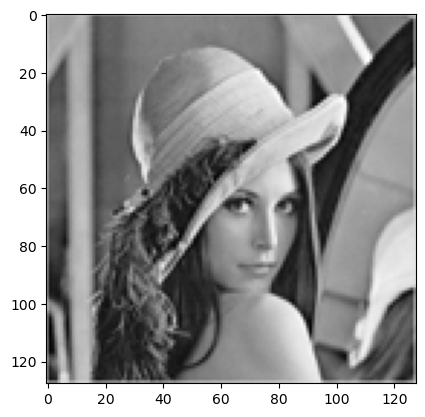

In [3]:
def load_grayscale_image(path, N=128):
    """
    Load image, convert to grayscale, resize/crop to NxN,
    and normalize pixel values to [0, 1].
    """
    img = Image.open(path).convert("L")  # L = grayscale

    # Resize if needed (keeps things simple)
    if img.size != (N, N):
        img = img.resize((N, N), resample=Image.BICUBIC)

    x = np.asarray(img, dtype=np.float64)

    # Normalize to [0, 1]
    x = (x - x.min()) / (x.max() - x.min()) #the image i use is already normalized 

    return x

x_img = load_grayscale_image('woman.png')
plt.imshow(x_img, cmap="gray")
print('Image shape:', x_img.shape)

Shape of blurred image: (128, 128)


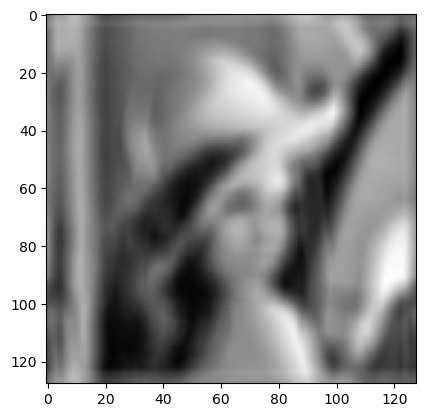

In [4]:
def uniform_blur_kernel(k=9):
    """
    Uniform blur kernel of dimension k
    """
    h = np.ones((k, k))
    h /= h.sum()
    return h
def uniform_blur_kernel(k=9):
    """
    Uniform blur kernel of dimension k
    """
    h = np.ones((k, k))
    h /= h.sum()
    return h

def A(x_img, h):
    return convolve2d(x_img, h, mode="same", boundary="wrap")

def AT(x_img, h):
    h_flip = h[::-1, ::-1]
    return convolve2d(x_img, h_flip, mode="same", boundary="wrap")

def add_blur(x_img,h, sigma=0.05):
    return A(x_img,h) + sigma * np.random.randn(*x_img.shape)


h = uniform_blur_kernel()
y_img = add_blur(x_img,h,sigma=0.0024)
plt.imshow(y_img, cmap='gray')
print('Shape of blurred image:', y_img.shape)

def setup_fft_operators(h, y_img):
    shape = y_img.shape

    # FFT of kernel padded to image size
    H = np.fft.fft2(h, s=shape)
    H_conj = np.conj(H)

    # Precompute A^T y
    Y_hat = np.fft.fft2(y_img)
    b_hat = H_conj * Y_hat
    b = np.fft.ifft2(b_hat).real

    return H, H_conj, b



In [5]:
def grad_data_fft(x_img, H, H_conj, b, sigma):
    X_hat = np.fft.fft2(x_img)

    # Compute A^T A x in Fourier domain
    Ax_hat = H * X_hat
    ATAx_hat = H_conj * Ax_hat
    ATAx = np.fft.ifft2(ATAx_hat).real

    return (ATAx - b) / sigma**2


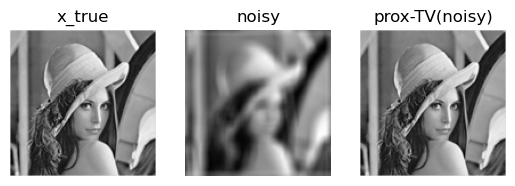

In [6]:
def grad_forward(x):
    gx = np.roll(x, -1, axis=0) - x
    gy = np.roll(x, -1, axis=1) - x
    return gx, gy
def div_backward(px, py):
    return (
        px - np.roll(px, 1, axis=0)
        + py - np.roll(py, 1, axis=1)
    )
def tv_norm(x):
    gx, gy = grad_forward(x)
    return np.sum(np.abs(gx) + np.abs(gy))
#dealing with non differentiability
def prox_tv_chambolle(x, lam, n_iter=50):
    """
    Compute prox_{lam * TV}(x) using Chambolle's algorithm.
    lam > 0 controls denoising strength.
    """
    px = np.zeros_like(x)
    py = np.zeros_like(x)
    tau = 0.25  # stable step

    for _ in range(n_iter):
        div_p = div_backward(px, py)
        gx, gy = grad_forward(div_p - x / lam)

        px_new = px + tau * gx
        py_new = py + tau * gy

        # projection step: enforce |p| <= 1 pointwise
        norm = np.maximum(1.0, np.sqrt(px_new**2 + py_new**2))
        px = px_new / norm
        py = py_new / norm

    # primal solution
    return x - lam * div_backward(px, py)


def grad_tv_moreau(x, lam, theta=10.74, n_iter=50):
        """
        Gradient of the Moreau-Yosida envelope of g(x)=theta*TV(x).
        """
        prox = prox_tv_chambolle(x, lam*theta, n_iter=n_iter)
        return (x - prox) / lam



x_denoised = prox_tv_chambolle(x_img, lam=2.83e-5, n_iter=100)

plt.subplot(1,3,1); plt.imshow(x_img, cmap="gray"); plt.title("x_true"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(y_img, cmap="gray"); plt.title("noisy"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(x_denoised, cmap="gray"); plt.title("prox-TV(noisy)"); plt.axis("off")
plt.show()

In [7]:
def gradU_img(x_img, H, H_conj, b, sigma, lam, theta, m):
    return (
        grad_data_fft(x_img, H, H_conj, b, sigma)
        + grad_tv_moreau(x_img, lam, theta)
        + m * x_img
    )

def make_gradU(H, H_conj, b, sigma, lam, theta, m, shape=(128,128)):
    def gradU_vector(x_vec):
        x_img = x_vec.reshape(shape)
        g_img = gradU_img(
            x_img,
            H=H,
            H_conj=H_conj,
            b=b,
            sigma=sigma,
            lam=lam,
            theta=theta,
            m=m
        )
        return g_img.reshape(-1)
    return gradU_vector




In [ ]:
from langevin_samplers import (
    run_hmc,
    run_k_langevin,
    run_od_langevin,
    run_od_langevin_streaming
)

sigma = 0.0024
lam = 2.83e-5
theta=10.74
m=1

x_img = load_grayscale_image('woman.png', N=128)
y_img = add_blur(x_img,h, sigma=sigma)

x0 = vec(y_img.copy())
v0 = np.random.randn(*x0.shape)

H, H_conj, b = setup_fft_operators(h, y_img)
gradU = make_gradU(
    H=H,
    H_conj=H_conj,
    b=b,
    sigma=sigma,
    lam=lam,
    theta=theta,
    m=m
)

mean_x = run_od_langevin_streaming(
    x0,
    v0,
    gradU,
    N=1000000,
    delta=1e-3,
    K=1,
    eta=0.0,
    burn=20000,
    thin=10
)



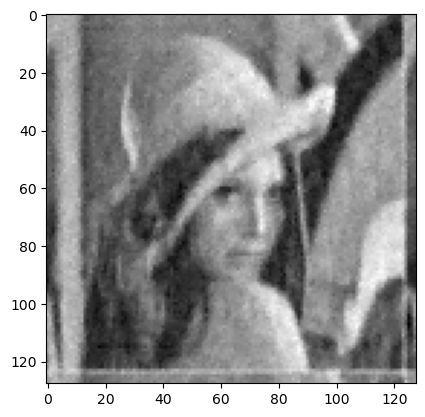

In [ ]:
plt.imshow(mean_x.reshape(128,128), cmap="gray")
